# Practica de Laboratorio Nº2: Caracterizacion del ruido del canal inhalambrico.

In [341]:
#---------------------------------------------------------------------------------
#Project     : Caracterizacion del ruido del canal inhalambrico
# Authors    : Brigido Tomas Andres, Lugones Oviedo Facundo Luis, Tosolini Agustin
# Affiliation: UNC
# E-mail     : 
#---------------------------------------------------------------------------------

In [342]:
#! pip install pyadi-iio
#! pip install matplotlib
#! pip install scikit-dsp-comm
#! pip install scikit-commpy

Importamos las siguientes biblioteca:

In [343]:
#------------------------------- Libraries ------------------------------- 
import adi
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

esto permitirá tener acceso a distintas clases de Python, entre las cuales se encuentran las asociadas al SDR y a los AD936x. Con estas clases se pueden generar objetos cuyas propiedades van a ser utilizadas para reconfigurar el hardware en cuestión. 

In [344]:
def _normalize_rx_signal(signal):
    return signal[0] if isinstance(signal, (list, tuple)) else signal

def plotSignal(signal):
    x = _normalize_rx_signal(signal)
    I = np.real(x)
    Q = np.imag(x)

    plt.figure(figsize=(12, 4))
    plt.plot(I, label='I', linewidth=1)
    plt.plot(Q, label='Q', linewidth=1)
    plt.title('Senal recibida en el tiempo')
    plt.xlabel('Indice de muestra')
    plt.ylabel('Amplitud')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plotSpect(signal, fs):
    x = _normalize_rx_signal(signal)
    X = np.fft.fftshift(np.fft.fft(x))
    f = np.fft.fftshift(np.fft.fftfreq(len(x), d=1/fs))
    psd_db = 20 * np.log10(np.abs(X) + 1e-12)

    plt.figure(figsize=(12, 4))
    plt.plot(f, psd_db, linewidth=1)
    plt.title('Espectro de la senal recibida')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Magnitud [dB]')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


En las siguientes lineas de código se crea el objeto "sdr" y se lo vincula con el dispositivo que se encuentra en la dirección proporcionada por la variable "Uri".

In [345]:
Uri = "ip:192.168.1.32"
sdr = adi.Pluto(Uri)

In [346]:
nSamples     = 2**20
samplingRate = 2.0e6
frec         = samplingRate/8

## Parámetros de configuración del SDR

In [347]:
#------------------------------- SDR Parameter Configuration -------------------------------
Uri              = Uri
Loopback         = 0             # 0=Disabled, 1=Digital loopback, 2=Retransmiter
SamplingRate     = samplingRate  # Sample rate RX and TX paths[Samples/Sec]

TxLOFreq         = 915e6         # Carrier frequency of TX path [Hz]
TxAtten          = -70           # Attenuation applied to TX path, valid range is -89 to 0 dB [dB]
TxRfBw           = 2.0e6         # Bandwidth of front-end analog filter of TX path [Hz]
RxBufferSize     = nSamples      # Depend on the length of the transmit signal. Maximum tx buffer size 2**24[samples]
tx_cyclic_buffer = False

RxLOFreq         = TxLOFreq      # Carrier frequency of RX path [Hz]
GainControlModes = "manual"      # Receive path AGC Options: slow_attack, fast_attack, manual
RxHardwareGain   = 70            # Gain applied to RX path. Only applicable when gain_control_mode is set to 'manual'    
RxRfBw           = TxRfBw        # Bandwidth of front-end analog filter of RX path [Hz] 
RxBufferSize     = 2**20         # Rx Buffer size. Maximun value 2**28 [Samples]

sdr.loopback = Loopback

## Frecuencia de muestreo
El segundo parámetro de configuración a describir es el "sdr.sample_rate". Este parámetro define la frecuencia a la cual el AD9363 va a estar procesando las muestras digitales correspondientes a las componentes en fase y en cuadratura de la parte transmisora y receptora. Para el caso en que los datos digitales sean generados o entregados un Host remoto de forma continua, como por ejemplo una computadora, la máxima frecuencia de muestreo a configurar va a depender del límite de velocidad soportado por el tipo de conexión al Host remoto.

- **Rango de la frec. de muestreo: 521 KSPS a 61.44 MSPS**

In [348]:
sdr.sample_rate = samplingRate  # Sample rate RX and TX paths[Samples/Sec]

## Ancho de banda en RF
En la parte receptora, la señal que sale de los mezcladores de RF es filtrada para eliminar los efectos de alias y para reducir la interferencia y el ruido fuera de banda. Un amplificador de transimpedancia (TIA) y un filtro analógico se configuran y funcionan de forma conjunta para mantener el ancho de banda analógico deseado, cuyo rango va desde los 200 kHz hasta los 20 MHz. El TIA actúa como un filtro de un polo y el filtro analógico es un filtro Butterworth de tercer orden programable.
- **Rango del ancho de banda en RF del transmisor y del receptor: 200Khz a 20 Mhz**

In [349]:
sdr.tx_rf_bandwidth = int(TxRfBw)  # Bandwidth of front-end analog filter of TX path [Hz]
sdr.rx_rf_bandwidth = int(RxRfBw)  # Bandwidth of front-end analog filter of RX path [Hz] 

# Ganancia de Hardware

In [350]:
sdr.tx_hardwaregain_chan0   = TxAtten # Attenuation applied to TX path, valid range is -90 to 0 dB [dB]
sdr.rx_hardwaregain_chan0   = RxHardwareGain   # Gain applied to RX path. Only applicable when gain_control_mode is set to 'manual'
sdr.gain_control_mode_chan0 = GainControlModes # Receive path AGC Options: slow_attack, fast_attack, manual

## Frecuencia de portadora
El transceptor cuenta con un par de mezcladores en cuadratura en la parte transmisora/receptora, los cuales permiten procesar/obtener las componentes en fase y cuadratura y realizar su traslado en frecuencia. Desde el punto de vista del receptor, la arquitectura implementada para llevar la señal de RF a banda base es la llamada conversión directa (o Zero Forcing). En este tipo de arquitectura no se hace uso de etapas de frecuencia intermedia. El rango de operación de los mezcladores va desde los 325 Mhz hasta los 3.8 Ghz, pero se pueden hacer [modificaciones](https://wiki.analog.com/university/tools/pluto/users/customizing) en el software para ampliar este rango.

- **Rango de los osciladores de RF en el transmisor y en el receptor: 325 Mhz a 3.800 Mhz**


In [351]:
sdr.tx_lo = int(TxLOFreq)# Carrier frequency of TX path [Hz]
sdr.rx_lo = int(RxLOFreq) # Carrier frequency of RX path [Hz]

## Buffers

In [352]:
sdr.rx_buffer_size   = RxBufferSize
sdr.tx_cyclic_buffer = tx_cyclic_buffer
#sdr._ctrl.context.set_timeout(0) # <- disable timeout if you want to use large buffer size

## Recibiendo el ruido del canal inhalambrico
Las lineas de código que permiten recibir el ruido captado por el SDR son:

In [353]:
#------------------------------- Receiver ------------------------------- 
rxSignal = sdr.rx()

# Se pasa a un vector de python para facilitar los calculos de la media y varianza
x = list(rxSignal)
N = len(x)

if N < 2:
    raise ValueError("Se necesitan al menos 2 muestras para varianza insesgada.")

# Media muestral
acum = 0
for xi in x:
    acum += xi
media = acum / N

# Varianza: suma de cuadrados respecto de la media
acum2 = 0
for xi in x:
    d = xi - media
    acum2 += abs(d) ** 2

# Varianza tipo MLE (divide por N)
var_mle = acum2 / N

print("Datos calculados con formula:")
print("Numero de muestras =", N)
print("Media =", media)
print("Varianza =", var_mle)

Datos calculados con formula:
Numero de muestras = 1048576
Media = (-0.012646675109863281-0.009179115295410156j)
Varianza = 221.53780932169275


In [354]:


# Para señal compleja:
mu_c = np.mean(x)                               # media compleja
var_c_mle = np.mean(np.abs(x - mu_c)**2)        # varianza (MLE, divide por N)

# Por componentes I/Q (útil para ruido en banda base)
I = np.real(x)
Q = np.imag(x)

mu_I = np.mean(I)
mu_Q = np.mean(Q)

var_I_mle = np.var(I, ddof=0)   # divide por N
var_Q_mle = np.var(Q, ddof=0)

print("\nDatos calulados con python:")
print(f"Numero de muestras = {N}")
print(f"Media = {mu_c}")
print(f"Media Real = {mu_I}")
print(f"Media Imaginaria = {mu_Q}")
print(f"Varianza = {var_c_mle}")
print(f"Var(Real) MLE = {var_I_mle}")
print(f"Var(Imaginaria) MLE = {var_Q_mle}")

print("\nComparacion de los datos:")
print(f"Meida calculada con formula: ",media)
print(f"Meida calculada con NumPy: ",mu_c)
print(f"Varianza calculada con formula: ",var_mle)
print(f"Varianza calculada con NumPy: ",var_c_mle)




Datos calulados con python:
Numero de muestras = 1048576
Media = (-0.012646675109863281-0.009179115295410156j)
Media Real = -0.012646675109863281
Media Imaginaria = -0.009179115295410156
Varianza = 221.5378093180243
Var(Real) MLE = 110.9688942837156
Var(Imaginaria) MLE = 110.5689150343087

Comparacion de los datos:
Meida calculada con formula:  (-0.012646675109863281-0.009179115295410156j)
Meida calculada con NumPy:  (-0.012646675109863281-0.009179115295410156j)
Varianza calculada con formula:  221.53780932169275
Varianza calculada con NumPy:  221.5378093180243


Gráfica temporal de la señal recibida

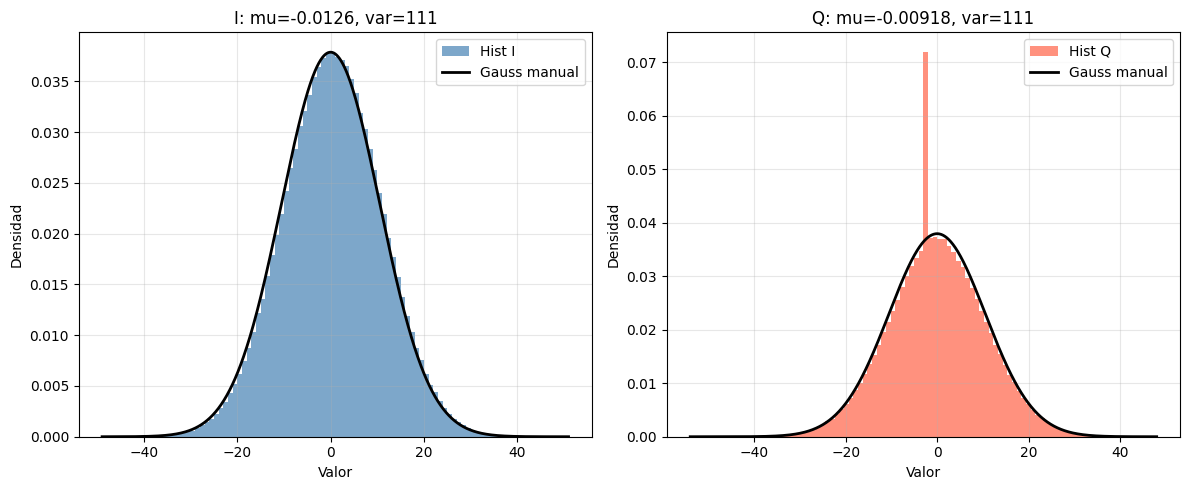

In [355]:

I = np.real(x)
Q = np.imag(x)

#plt.figure(figsize=(12, 8))
#
#plt.subplot(2, 2, 1)
## density = True normaliza el histograma a una función de densidad (área total = 1)
#plt.hist(I, bins=100, density=True, alpha=0.8, color="steelblue")
#plt.title("Histograma de I (parte real)")
#plt.xlabel("Valor")
#plt.ylabel("Densidad")
#plt.grid(True, alpha=0.3)
#
#plt.subplot(2, 2, 2)
#plt.hist(Q, bins=100, density=True, alpha=0.8, color="tomato")
#plt.title("Histograma de Q (parte imaginaria)")
#plt.xlabel("Valor")
#plt.ylabel("Densidad")
#plt.grid(True, alpha=0.3)

# -------------------- Parametros ajustables a mano --------------------
# Cambialos y volve a ejecutar la celda
mu_I_user  = mu_I
var_I_user = var_I_mle

mu_Q_user  = mu_Q
var_Q_user = var_Q_mle
# ---------------------------------------------------------------------

if var_I_user <= 0 or var_Q_user <= 0:
    raise ValueError("La varianza debe ser > 0")

def gaussian_pdf(z, mu, var):
    return (1.0 / np.sqrt(2.0 * np.pi * var)) * np.exp(-((z - mu) ** 2) / (2.0 * var))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histograma I + gaussiana manual
ax[0].hist(I, bins=100, density=True, alpha=0.7, color="steelblue", label="Hist I")
zI = np.linspace(np.min(I), np.max(I), 1000)
ax[0].plot(zI, gaussian_pdf(zI, mu_I_user, var_I_user), "k", lw=2, label="Gauss manual")
ax[0].set_title(f"I: mu={mu_I_user:.3g}, var={var_I_user:.3g}")
ax[0].set_xlabel("Valor")
ax[0].set_ylabel("Densidad")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# Histograma Q + gaussiana manual
ax[1].hist(Q, bins=100, density=True, alpha=0.7, color="tomato", label="Hist Q")
zQ = np.linspace(np.min(Q), np.max(Q), 1000)
ax[1].plot(zQ, gaussian_pdf(zQ, mu_Q_user, var_Q_user), "k", lw=2, label="Gauss manual")
ax[1].set_title(f"Q: mu={mu_Q_user:.3g}, var={var_Q_user:.3g}")
ax[1].set_xlabel("Valor")
ax[1].set_ylabel("Densidad")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

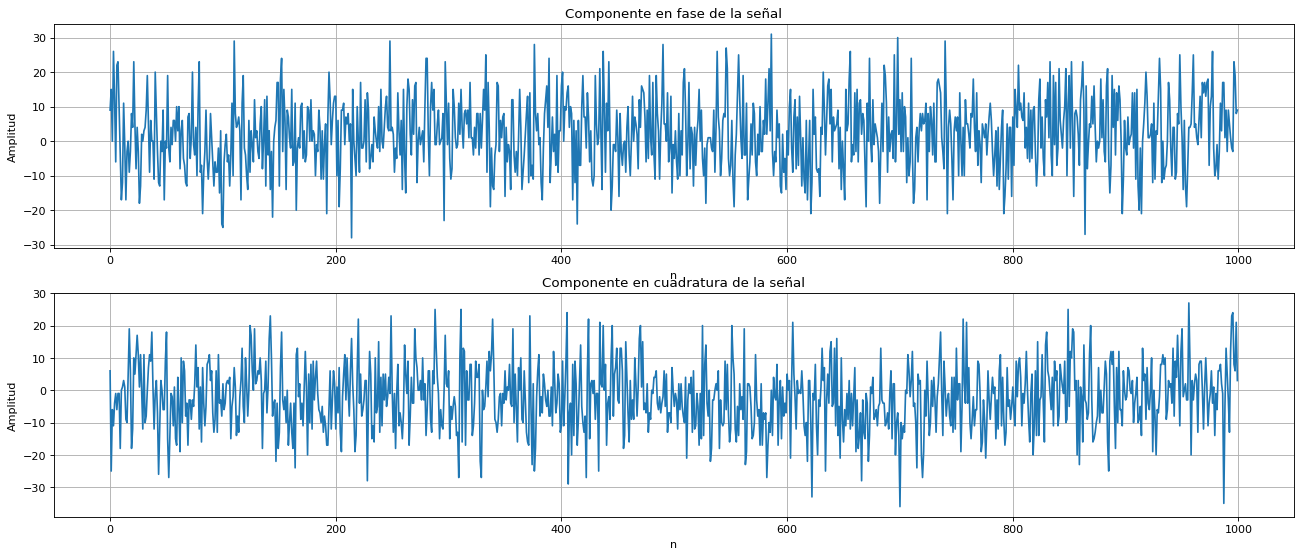

In [356]:

def plotSignal(signal):
#------------------------------- Transmitted I component ------------------------------- 
# Plot time domain
    plt.figure(figsize=(20,8), dpi= 80, facecolor='w', edgecolor='k')
    plt.subplot(2,1,1)
    plt.plot(np.real(signal))
    plt.xlabel('n')
    plt.ylabel('Amplitud')
    plt.title('Componente en fase de la señal')
    plt.grid()
#------------------------------- Transmitted Q component -------------------------------
# Plot time domain
    plt.subplot(2,1,2)
    plt.plot(np.imag(signal))
    plt.xlabel('n')
    plt.ylabel('Amplitud')
    plt.title('Componente en cuadratura de la señal')
    plt.grid()
    plt.show()
    
plotSignal(rxSignal[0:1000])

Gráfica de la densidad espectral de potencia de la señal recibida

/tmp/ipykernel_24834/2345143446.py:5: MatplotlibDeprecationWarning: Passing the NFFT parameter of psd() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.psd(signal, len(signal), samplingRate, color='C1')


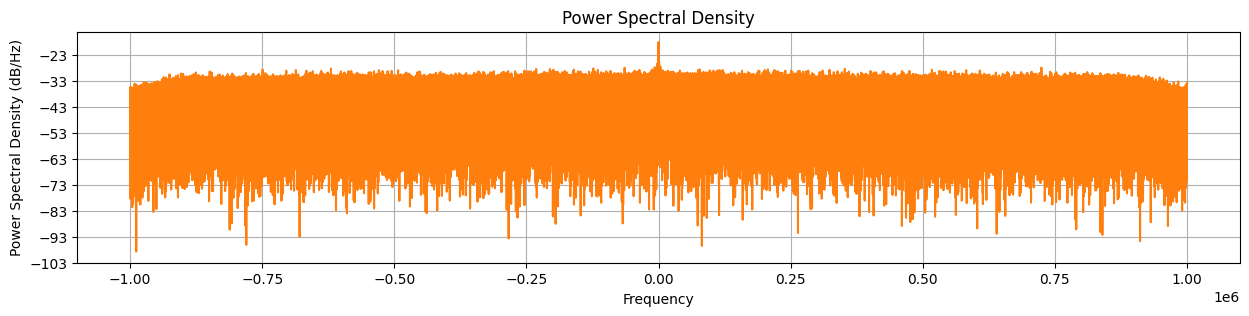

In [357]:
def plotSpect(signal,samplingRate):
    plt.subplots(figsize=(15, 3))
    plt.grid()
    plt.title("Power Spectral Density")
    plt.psd(signal, len(signal), samplingRate, color='C1')
    plt.show()
    
plotSpect(rxSignal,samplingRate)

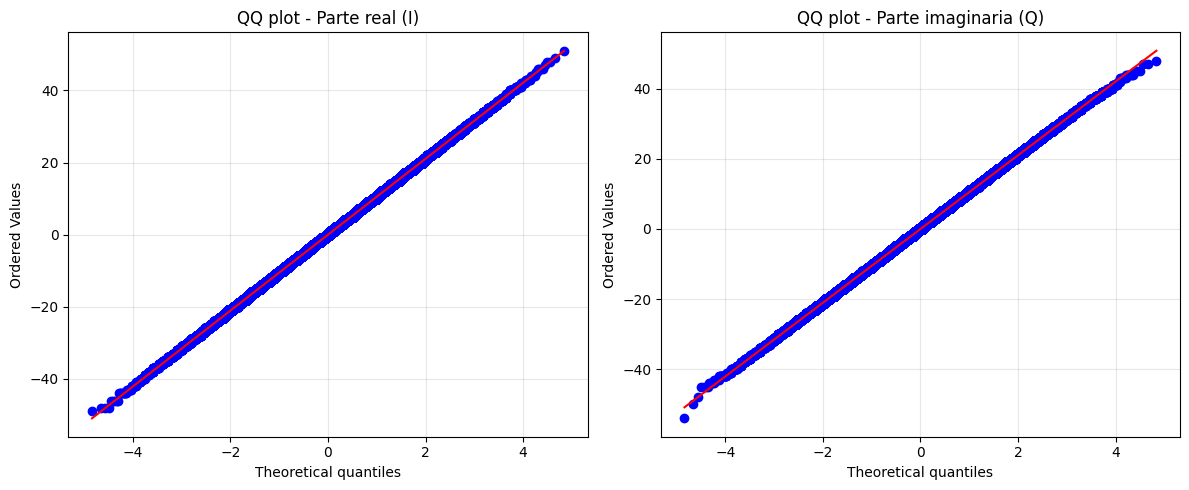

In [358]:
# Tomar canal 0 si rxSignal viene en lista/tupla
x = rxSignal[0] if isinstance(rxSignal, (list, tuple)) else rxSignal

I = np.real(x)
Q = np.imag(x)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# QQ plot para I
stats.probplot(I, dist="norm", plot=ax[0])
ax[0].set_title("QQ plot - Parte real (I)")
ax[0].grid(True, alpha=0.3)

# QQ plot para Q
stats.probplot(Q, dist="norm", plot=ax[1])
ax[1].set_title("QQ plot - Parte imaginaria (Q)")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [359]:
#num_symbols = 1000
#plt.figure(figsize=(3,3))
#plt.plot(np.real(rxSignal[0:num_symbols]),np.imag(rxSignal[0:num_symbols]),'b*')
#plt.grid()
#plt.show()

## Finalizando la experiencia
Dado que no es posible apagar la etapa transmisora del SDR, es recomendable antes de finalizar la experiencia, dejar configurado el transmisor con la máxima atenuación posible, asegurarse que las frecuencias de transmisión y recepción no coinciden y cargar al Buffer transmisor con ceros. Esto permitirá minimizar cualquier posible interferencia por parte del SDR.

In [360]:
# Since it is not possible to turn off Tx, it is configured to transmit at low power and on a different frequency than Rx.
sdr.tx_destroy_buffer()
sdr.tx_hardwaregain_chan0 = -89 
sdr.tx_lo                 = int(2400e6)
sdr.rx_lo                 = int(950e6)
sdr.tx(np.zeros(2048))

In [361]:
# Destroy radio object
del(sdr)

# Variable Gaussiana Temporal

mu_z = (-0.009776583966291122-0.0036626105486926835j)
var_z = 221.52879970946265  (objetivo: 221.53780932169275)


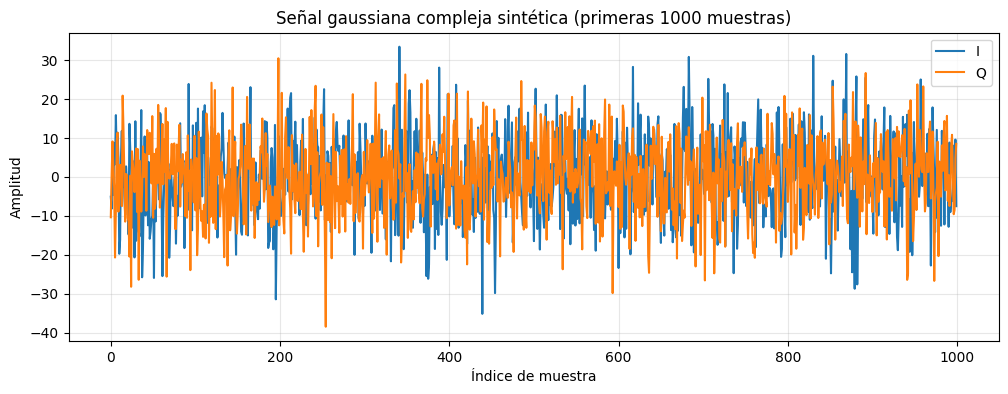

/tmp/ipykernel_24834/2345143446.py:5: MatplotlibDeprecationWarning: Passing the NFFT parameter of psd() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.psd(signal, len(signal), samplingRate, color='C1')


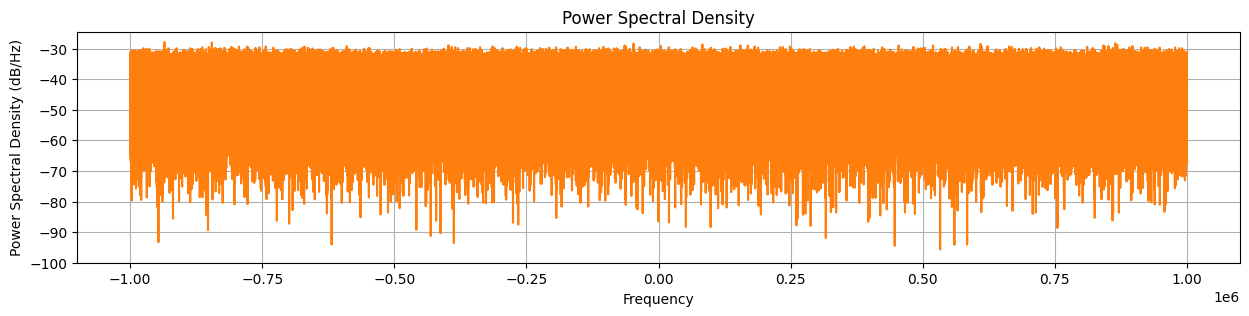

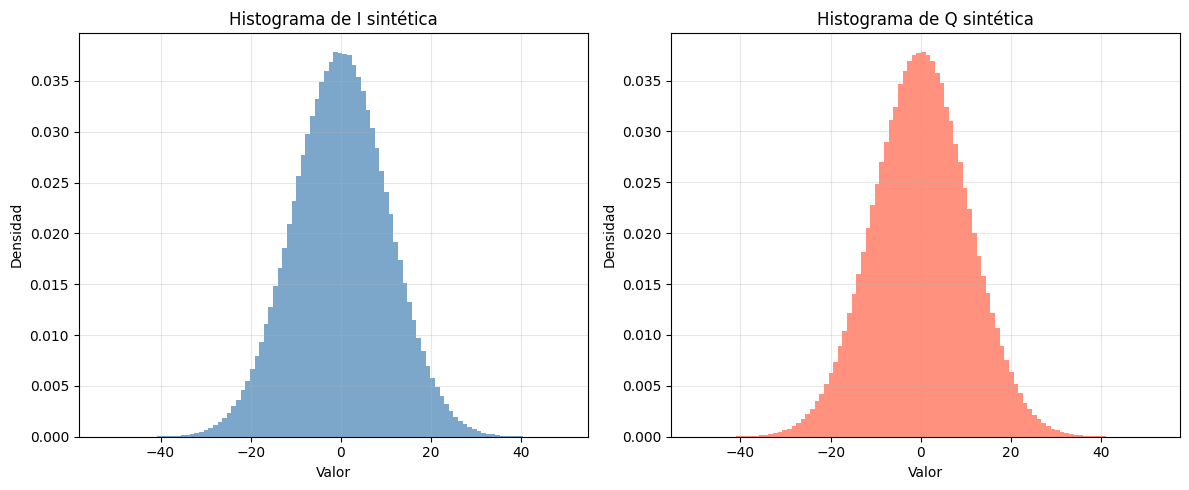

In [362]:
# Generar y analizar una señal gaussiana compleja usando valores fijos de la señal muestreada
N = nSamples
mu_c = mu_c
var_c_mle = var_mle

# Para ruido complejo circularmente simétrico:
# var_complex = var_I + var_Q = 2 * sigma^2
sigma = np.sqrt(var_c_mle / 2)

z = sigma * (np.random.randn(N) + 1j * np.random.randn(N)) + mu_c

mu_z = np.mean(z)
var_z = np.mean(np.abs(z - mu_z) ** 2)
print(f"mu_z = {mu_z}")
print(f"var_z = {var_z}  (objetivo: {var_c_mle})")

# Gráfica temporal de las primeras muestras
plt.figure(figsize=(12, 4))
plt.plot(np.real(z[:1000]), label='I')
plt.plot(np.imag(z[:1000]), label='Q')
plt.title('Señal gaussiana compleja sintética (primeras 1000 muestras)')
plt.xlabel('Índice de muestra')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Gráfica en frecuencia
#from scipy.fft import fft, fftfreq, fftshift
#Z = fftshift(fft(z))
#f = fftshift(fftfreq(N, d=1/samplingRate))
#plt.figure(figsize=(10, 4))
#plt.plot(f, 20 * np.log10(np.abs(Z) + 1e-12))
#plt.title('Espectro de la señal gaussiana compleja sintética')
#plt.xlabel('Frecuencia (Hz)')
#plt.ylabel('Magnitud (dB)')
#plt.grid(True, alpha=0.3)
#plt.xlim(-samplingRate / 2, samplingRate / 2)
#plt.show()
plotSpect(z,samplingRate)
# Histogramas de I y Q
I_z = np.real(z)
Q_z = np.imag(z)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(I_z, bins=100, density=True, alpha=0.7, color='steelblue')
plt.title('Histograma de I sintética')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(Q_z, bins=100, density=True, alpha=0.7, color='tomato')
plt.title('Histograma de Q sintética')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Conclusion

A partir de la configuración del PlutoSDR y de la adquisición de un bloque grande de muestras complejas en banda base, fue posible caracterizar el ruido presente en el canal inalámbrico desde una perspectiva temporal, espectral y estadística. El procedimiento implementado permitió fijar los parámetros principales del receptor, capturar el ruido con una frecuencia de muestreo conocida y analizarlo mediante su media, su varianza y la separación de sus componentes en fase y cuadratura.

Los resultados obtenidos muestran que la media compleja del ruido es cercana a cero, mientras que la varianza total medida se reparte de manera aproximadamente equilibrada entre las componentes I y Q. Este comportamiento es consistente con el modelo habitual de ruido aditivo gaussiano complejo en banda base, donde ambas componentes pueden interpretarse como variables aleatorias gaussianas de media pequeña y dispersión similar. Los histogramas y los QQ plots refuerzan esta interpretación, ya que permiten observar una forma aproximadamente normal para ambas componentes, aunque con pequeñas desviaciones esperables en una medición real sobre hardware.

Por otra parte, el análisis espectral de la señal recibida permite verificar que la energía del ruido se distribuye sobre la banda observada sin estructura determinística dominante, lo cual es coherente con un proceso esencialmente aleatorio. La comparación posterior con una señal gaussiana compleja sintética generada a partir de la media y la varianza estimadas resulta útil para validar el modelo, ya que la señal simulada reproduce un comportamiento estadístico similar al de la medición experimental. Esto confirma que, para fines de modelado y simulación, el ruido medido puede aproximarse razonablemente mediante una variable gaussiana compleja circularmente simétrica.

En conclusión, la experiencia permite afirmar que el ruido captado por el sistema receptor puede describirse de forma satisfactoria mediante un modelo de ruido gaussiano complejo en banda base, con media próxima a cero, componentes I y Q de comportamiento semejante, y una distribución espectral compatible con un proceso aleatorio. Esta caracterización es fundamental para etapas posteriores del trabajo en comunicaciones digitales, ya que proporciona un modelo realista del canal y una base cuantitativa para evaluar detección, demodulación y desempeño de sistemas frente al ruido.